## Anamoly Detection

* Isolation Forest
* DBSCAN
* Local Outlier Factor

### Isolation Forest

Isolation Forest detects anomalies by randomly partitioning the data using decision trees. Since anomalous points are few and different, they get isolated quickly with fewer splits, making them easy to identify as outliers.

In [48]:
## Reading the data
import pandas as pd
df = pd.read_csv('healthcare.csv')
df.head()

,0,1
0,1.616671,1.944522
1,1.256461,1.609444
2,-2.343919,4.392961
3,1.195393,2.794485
4,-3.329586,5.303160


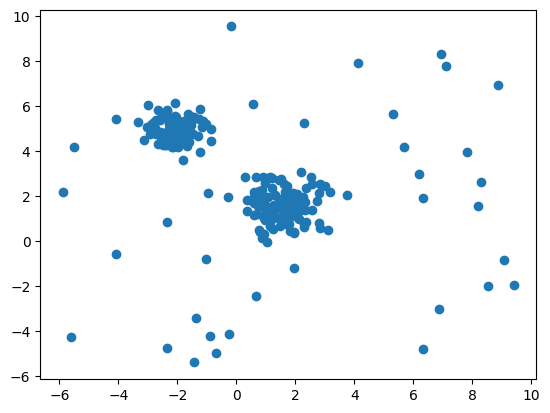

In [49]:
## Visualize the data
import matplotlib.pyplot as plt
plt.scatter(df.iloc[:,0], df.iloc[:,1])

In [50]:
## Importing IsolationForest
from sklearn.ensemble import IsolationForest

In [51]:
## Applying Isolation on df
isolation = IsolationForest(contamination=0.1)
isolation.fit(df)
isolation_prediction = isolation.predict(df)
isolation_prediction

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1, -1,  1,  1,
        1,  1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1, -1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1, -1,  1,  1,
        1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1, -1,  1,  1, -1,
       -1,  1,  1,  1,  1

In [52]:
## Getting index of outliers
import numpy as np
iso_outlier_index = np.where(isolation_prediction < 0)
iso_outlier_index

(array([ 20,  45,  48,  53,  55,  72,  74,  85,  87,  92, 108, 119, 130,
        133, 141, 151, 167, 179, 212, 217, 220, 221, 227, 242, 247]),)

In [53]:
X = df.values

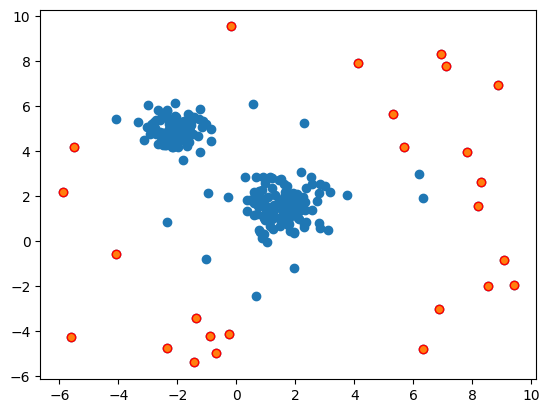

In [54]:
## Visualize the Normal Data points and Outliers
plt.scatter(df.iloc[:,0], df.iloc[:,1])
plt.scatter(X[iso_outlier_index,0], X[iso_outlier_index,1], edgecolors="r")

### DBSCAN Clustering
DBSCAN identifies anomalies as noise points that do not belong to any dense cluster. It is useful when clusters have irregular shapes and when we want to separate outliers naturally without predefining the number of clusters.

In [55]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
%matplotlib inline

In [56]:
## Creating the dataset and using only X
X, y = make_circles(n_samples=1000, factor=0.3, noise=0.2)
X

array([[ 0.31998803, -0.92949237],
       [-0.04420883, -0.02495604],
       [ 0.86339066,  0.14879341],
       ...,
       [ 0.14066167,  1.14105889],
       [ 0.56386903, -0.05727328],
       [-0.3599021 ,  0.20745383]], shape=(1000, 2))

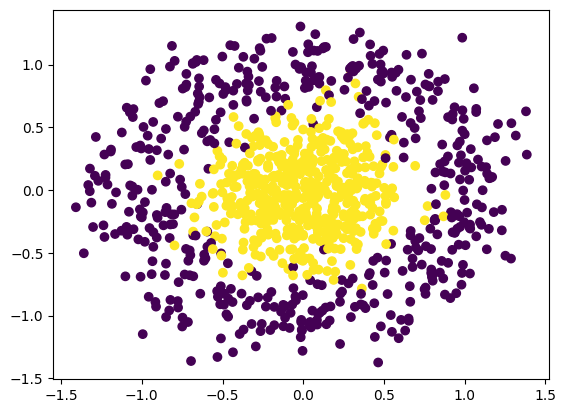

In [57]:
## Plotting the dataset
plt.scatter(X[:,0], X[:,1], c=y)

In [58]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.10)
dbscan.fit_predict(X)

array([ 0,  1,  2,  1,  1,  1,  1, -1,  3,  1,  4, -1,  1,  1,  1, 13, -1,
        1, -1,  1,  1,  4, -1,  1, 20,  5,  6,  1,  4,  1,  7,  1, -1,  1,
        1,  1, -1,  3,  4,  1,  1, -1,  4,  4,  1,  1, -1,  1,  1,  8, 15,
        3,  1,  1,  1,  9,  4, -1, 18, 10,  1,  5,  1, 10,  1, 11, 12,  3,
        1,  1, 11,  1,  4,  3,  1,  1, 11,  1, 11,  1,  1,  4, 12,  1,  1,
        0, 20,  7,  5,  1,  1,  1, 12,  1,  6, 11,  1,  1,  5,  1,  8, 13,
        1, -1,  1,  1, 14,  1,  1,  1,  1,  1,  1, -1, 12,  1, 15, 11,  2,
       -1,  7,  1,  5,  4,  1,  1, 11,  1, -1,  4, -1,  2,  1,  1,  1,  1,
        7,  1, 10,  2,  1,  1,  1, -1,  1, 11, 13,  1,  1,  1,  4, -1,  1,
       -1, 11,  1,  1,  1,  1,  2,  1,  1,  1, 16,  1,  1,  5, -1,  1,  0,
       11,  1, 16, 11,  1,  1, 19,  1,  1, 11, 16,  1,  1,  1, -1,  1, -1,
       10,  1,  1, -1,  1, -1,  1, 11,  1,  4,  1,  1,  1,  1, 11, 19, 12,
        1,  1, -1, 12, -1,  4, -1,  1,  1,  8, -1, 13, 18, -1,  1,  1,  1,
        1,  1, 12,  1,  1

In [59]:
dbscan.labels_

array([ 0,  1,  2,  1,  1,  1,  1, -1,  3,  1,  4, -1,  1,  1,  1, 13, -1,
        1, -1,  1,  1,  4, -1,  1, 20,  5,  6,  1,  4,  1,  7,  1, -1,  1,
        1,  1, -1,  3,  4,  1,  1, -1,  4,  4,  1,  1, -1,  1,  1,  8, 15,
        3,  1,  1,  1,  9,  4, -1, 18, 10,  1,  5,  1, 10,  1, 11, 12,  3,
        1,  1, 11,  1,  4,  3,  1,  1, 11,  1, 11,  1,  1,  4, 12,  1,  1,
        0, 20,  7,  5,  1,  1,  1, 12,  1,  6, 11,  1,  1,  5,  1,  8, 13,
        1, -1,  1,  1, 14,  1,  1,  1,  1,  1,  1, -1, 12,  1, 15, 11,  2,
       -1,  7,  1,  5,  4,  1,  1, 11,  1, -1,  4, -1,  2,  1,  1,  1,  1,
        7,  1, 10,  2,  1,  1,  1, -1,  1, 11, 13,  1,  1,  1,  4, -1,  1,
       -1, 11,  1,  1,  1,  1,  2,  1,  1,  1, 16,  1,  1,  5, -1,  1,  0,
       11,  1, 16, 11,  1,  1, 19,  1,  1, 11, 16,  1,  1,  1, -1,  1, -1,
       10,  1,  1, -1,  1, -1,  1, 11,  1,  4,  1,  1,  1,  1, 11, 19, 12,
        1,  1, -1, 12, -1,  4, -1,  1,  1,  8, -1, 13, 18, -1,  1,  1,  1,
        1,  1, 12,  1,  1

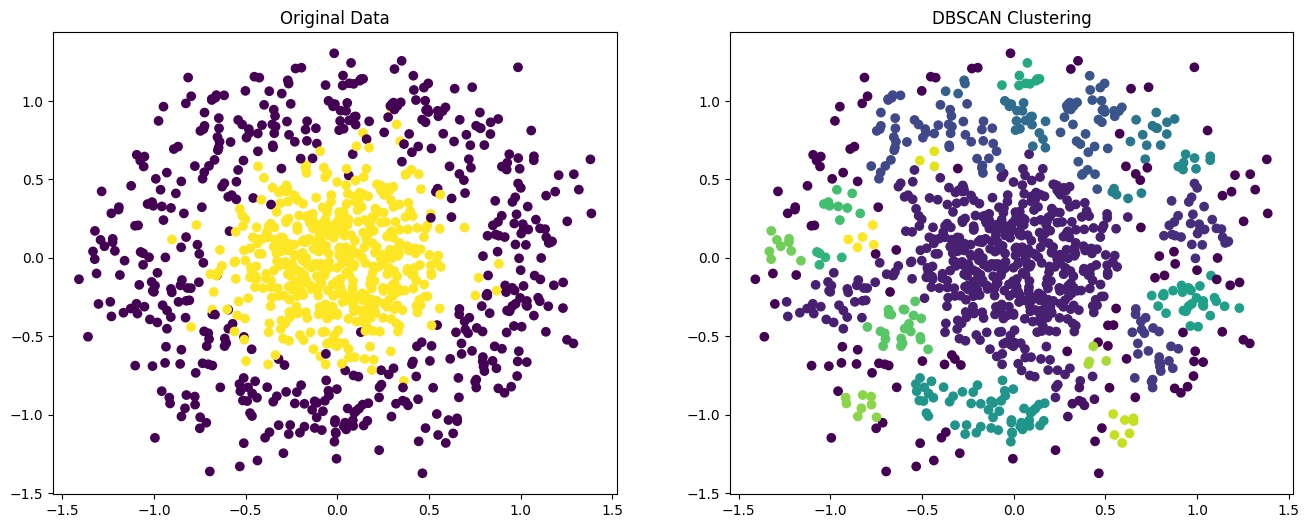

In [67]:
## Plotting side by side
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.title("Original Data")
plt.scatter(X[:,0], X[:,1], c=y)
plt.subplot(1,2,2)
plt.title("DBSCAN Clustering")
plt.scatter(X[:,0], X[:,1], c=dbscan.labels_)

* Both Isolation Forest and DBSCAN are effective techniques for identifying outliers in datasets. 
* Isolation Forest isolates anomalies by randomly selecting features and splitting values, making it efficient for high-dimensional data. 
* DBSCAN, on the other hand, clusters data points based on density, identifying outliers as points that do not belong to any cluster. 
* While Isolation Forest is particularly useful for large datasets with complex structures, DBSCAN excels in scenarios where the data has a clear density-based structure. 
* The choice between the two methods depends on the specific characteristics of the dataset and the nature of the outliers being targeted.

### Local Outlier Factor (LOF)
LOF detects anomalies by comparing the local density of a data point with the density of its nearest neighbors. If a point has much lower density than its neighbors, it is considered an outlier.

In [68]:
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
y_pred = lof.fit_predict(X)
y_pred

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1, -1,  1,  1, -1,  1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1, -1, -1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,
        1,  1,  1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,
        1,  1,  1,  1,  1

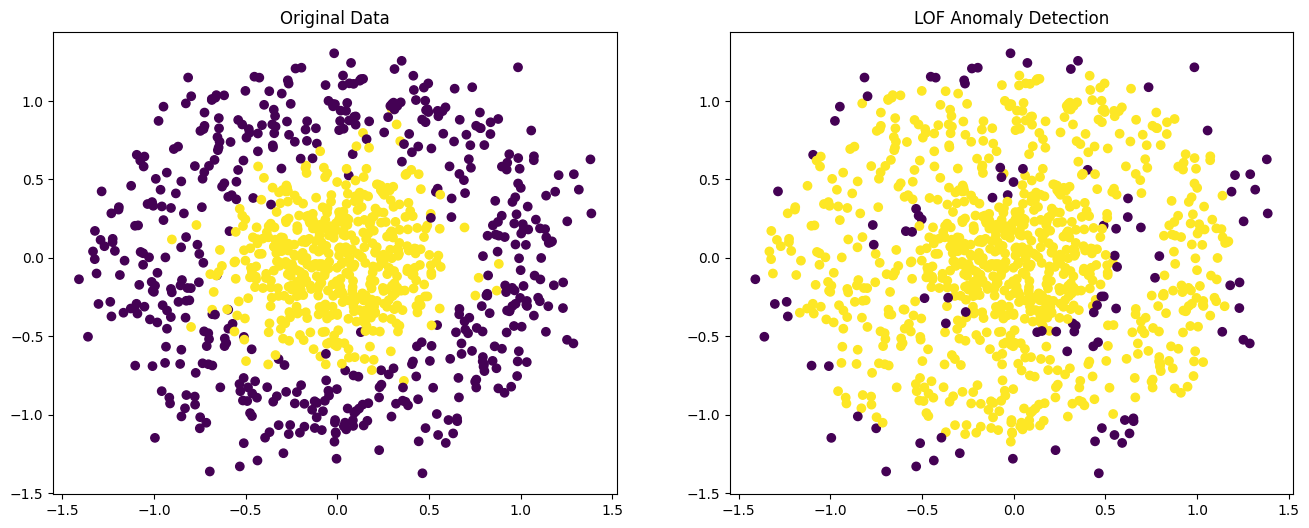

In [ ]:
## Plotting the results
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.title("Original Data")
plt.scatter(X[:,0], X[:,1], c=y)
plt.subplot(1,2,2)
plt.title("LOF Anomaly Detection")
plt.scatter(X[:,0], X[:,1], c=y_pred)


#### Conclusion

* In this notebook, we explored three different anomaly detection techniques: Isolation Forest, DBSCAN, and Local Outlier Factor (LOF), and analyzed their behavior using visual plots. Isolation Forest proved to be effective in identifying outliers in the healthcare dataset, clearly marking anomalous points as isolated (red points) in the scatter plot. This shows its strength in handling general anomaly detection problems, especially in high-dimensional data.

* DBSCAN performed well in identifying clusters in the circular dataset and naturally detected anomalies as noise points. However, it may misclassify some boundary points as noise when cluster density varies. LOF, on the other hand, effectively detected anomalies by comparing local densities, making it suitable for identifying subtle, neighborhood-based outliers in the circular data.

* Overall, each method has its own strengths and is suitable for different data distributions and anomaly patterns. Isolation Forest is best for general-purpose anomaly detection, while DBSCAN and LOF are more effective for density-based and local anomaly detection tasks. The choice of method should depend on the dataset characteristics and the type of anomalies of interest. Parameter tuning and, in some cases, combining multiple methods can further improve anomaly detection performance in real-world applications.